In [16]:
! pip install langchain_community
! pip install pypdf
! pip install -qU PyMuPDF pillow langchain-openai IPython

! pip install -qU langchain-community beautifulsoup4 unstructured
! pip install -qU langchain-unstructured

In [4]:
file_path = "deepseek.pdf"

from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader(file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)

from langchain_core.documents import Document
print(pages[0].page_content)


Ignoring wrong pointing object 10 0 (offset 0)
Ignoring wrong pointing object 21 0 (offset 0)
Ignoring wrong pointing object 32 0 (offset 0)


《Deepseek R1 本地部署完全⼿册》
版权归：HomeBrew Ai Club          
作者wechat：samirtan
版本：V2.0          
更新⽇期：2025年2⽉8⽇
⼀、简介
Deepseek R1 是⽀持复杂推理、多模态处理、技术⽂档⽣成的⾼性能通⽤⼤语⾔模型。本⼿册
为技术团队提供完整的本地部署指南，涵盖硬件配置、国产芯⽚适配、量化⽅案、云端替代⽅
案及完整671B MoE模型的Ollama部署⽅法。
核⼼提示：
个⼈⽤户：不建议部署32B及以上模型，硬件成本极⾼且运维复杂。
企业⽤户：需专业团队⽀持，部署前需评估ROI（投资回报率）。
⼆、本地部署核⼼配置要求
1. 模型参数与硬件对应表
模型参
数 Windows 配置要求 Mac 配置要求 适⽤场景
1.5B
- RAM: 4GB
- GPU: 集成显卡/现代CPU
- 存储: 5GB
- 内存: 8GB
（M1/M2/M3）
- 存储: 5GB
简单⽂本⽣成、基础代
码补全
7B
- RAM: 8-10GB
- GPU: GTX 1680（4-bit量
化）
- 存储: 8GB
- 内存: 16GB（M2
Pro/M3）
- 存储: 8GB
中等复杂度问答、代码
调试
14B
- RAM: 24GB
- GPU: RTX 3090（24GB
VRAM）
- 存储: 20GB
- 内存: 32GB（M3
Max）
- 存储: 20GB
复杂推理、技术⽂档⽣
成
32B+企业级部署（需多卡并联）暂不⽀持 科研计算、⼤规模数据
处理


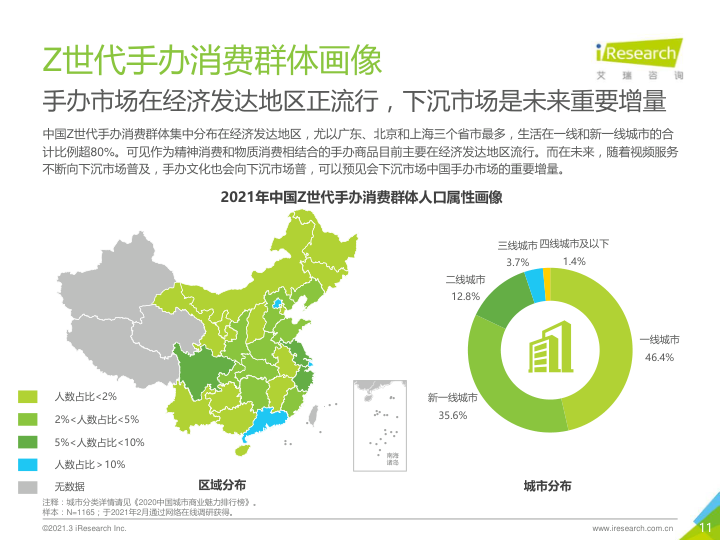

In [8]:

import base64
import io
import fitz
from PIL import Image

from IPython.display import Image as IPImage, display
file_path2 = "z2021.pdf"


def pdf_page_to_base64(pdf_path:str, page_number:int):
  pdf_document = fitz.open(pdf_path)
  page = pdf_document.load_page(page_number - 1)
  pix = page.get_pixmap()
  img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

  buffer = io.BytesIO()
  img.save(buffer, format="PNG")

  return base64.b64encode(buffer.getvalue()).decode("utf-8")


base64_image = pdf_page_to_base64(file_path2, 11)
display(IPImage(data=base64.b64decode(base64_image)))

In [15]:
import os

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

load_dotenv()  

llm = ChatOpenAI(
    model="mimo-v2.5", 
    api_key=os.environ["XIAOMI_API_KEY"],
    base_url="https://token-plan-cn.xiaomimimo.com/v1",
)

query = "一线城市消费者占比多少"

message = HumanMessage(
  content=[
    {"type":"text", "text":query},
    {"type":"image_url",
    "image_url":  {"url": f"data:image/png;base64,{base64_image}"}
    }
  ]
)

response = llm.invoke([message])
print(response)

content='根据您提供的图片，在“2021年中国Z世代手办消费群体人口属性画像”图表的右侧饼状图（城市分布）中显示：\n\n**一线城市消费者占比为 46.4%。**\n\n如果您需要新一线城市的数据，占比为 35.6%。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 146, 'prompt_tokens': 627, 'total_tokens': 773, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 80, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 192, 'image_tokens': 374}}, 'model_provider': 'openai', 'model_name': 'mimo-v2.5', 'system_fingerprint': None, 'id': '3d73d9bd620346779ed9ca9e12ca0e19', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e5d37-feb8-7d30-8689-13f8bc845017-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 627, 'output_tokens': 146, 'total_tokens': 773, 'input_token_details': {'cache_read': 192}, 'output_token_details': {'reasoning': 80}}


In [20]:
import bs4
from langchain_community.document_loaders import WebBaseLoader

page_url = "https://docs.langchain.com/oss/python/langchain/overview"

loader = WebBaseLoader(web_paths=[page_url])
docs = []
async for doc in loader.alazy_load():
    docs.append(doc)

assert len(docs) == 1
doc = docs[0]

print(f"{doc.metadata}\n")
print(doc.page_content[:500].strip())

Fetching pages: 100%|##########| 1/1 [00:00<00:00,  3.94it/s]

{'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}

LangChain overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdva


In [21]:
! pip install aiofiles

In [22]:
from typing import AsyncIterator, Iterator

from langchain_core.document_loaders import BaseLoader
from langchain_core.documents import Document


class CustomDocumentLoader(BaseLoader):
    """逐行读取文件的文档加载器示例"""

    def __init__(self, file_path: str) -> None:
        """使用文件路径初始化加载器

        参数:
            file_path: 要加载的文件路径
        """
        self.file_path = file_path

    def lazy_load(self) -> Iterator[Document]:  # <-- 不接受任何参数
        """逐行读取文件的惰性加载器

        当实现惰性加载方法时,你应该使用生成器
        一次生成一个文档
        """
        with open(self.file_path, encoding="utf-8") as f:
            line_number = 0
            for line in f:
                yield Document(
                    page_content=line,
                    metadata={"line_number": line_number, "source": self.file_path},
                )
                line_number += 1

    # alazy_load 是可选的
    # 如果不实现它,将使用一个默认实现,该实现会委托给 lazy_load!
    async def alazy_load(
        self,
    ) -> AsyncIterator[Document]:  # <-- 不接受任何参数
        """逐行读取文件的异步惰性加载器"""
        # 需要 aiofiles (通过 pip 安装)
        # https://github.com/Tinche/aiofiles
        import aiofiles

        async with aiofiles.open(self.file_path, encoding="utf-8") as f:
            line_number = 0
            async for line in f:
                yield Document(
                    page_content=line,
                    metadata={"line_number": line_number, "source": self.file_path},
                )
                line_number += 1



with open("meow.txt", "w", encoding="utf-8") as f:
    quality_content = "meow meow🐱 \n meow meow🐱 \n meow😻😻"
    f.write(quality_content)

loader = CustomDocumentLoader("meow.txt")


## 测试懒加载
for doc in loader.lazy_load():
    print()
    print(type(doc))
    print(doc)


<class 'langchain_core.documents.base.Document'>
page_content='meow meow🐱 
' metadata={'line_number': 0, 'source': 'meow.txt'}

<class 'langchain_core.documents.base.Document'>
page_content=' meow meow🐱 
' metadata={'line_number': 1, 'source': 'meow.txt'}

<class 'langchain_core.documents.base.Document'>
page_content=' meow😻😻' metadata={'line_number': 2, 'source': 'meow.txt'}
